In [2]:
# ============================================
# Jupyter Script: GP 自动挖掘 + 过滤 + 保存
# ============================================

from factors.factor_auto_search import GeneticFactorGenerator
import pandas as pd

# 1) 初始化 GeneticFactorGenerator（基于你给的参数）
fg = GeneticFactorGenerator(
    instrument_id_list='C0',
    start_time='20200101',
    end_time='20241231',
    version='20260330_gp_test',
    calculate_baseline=True,
    max_factor_count=50,
    rolling_norm_clip=5.0,  # 限制最大杠杆比
    gp_generations=30,
    fitness_metric='ic',
    gp_max_depth=4,
    gp_population_size=150,  # 每轮生成的因子数量
    gp_elite_size=30,        # 每轮前gp_elite_size个因子直接保留（不变异）进入下一轮
    gp_elite_relative_threshold=0.75,
    gp_leaf_prob=0.3,
    gp_const_prob=0.02,
    gp_window_choices=[5, 10, 20],
    gp_depth_penalty_coef=0.0,
    gp_depth_penalty_start_depth=4,
    gp_depth_penalty_linear_coef=0.05,
    gp_depth_penalty_quadratic_coef=0.0,
    gp_early_stopping_generation_count=20,
    random_seed=42,
    # 新增参数（你要求）
    gp_assumed_initial_capital=100000,
    gp_small_factor_penalty_coef=0.0,
)

# 2) 过滤阈值（沿用项目内日常脚本的默认思路）
filter_indicator_dict = {
    'Net Return': (0.05, 0.03, 1),
    'Net Sharpe': (0.5, 0.3, 1),
}

# 3) 一键执行：自动挖掘 + 筛选 + 保存
result = fg.auto_mine_select_and_save_fc(
    filter_indicator_dict=filter_indicator_dict,
    n_jobs=5,
    require_all_row=True,
    require_all_instruments=True,
)

# 4) 查看结果
print("config_path:", result.get("config_path"))
print("selected_count:", len(result.get("selected_fc_name_list", [])))
print("selected_fc_name_list:", result.get("selected_fc_name_list", []))

bt = result.get("bt")
if bt is not None and getattr(bt, "performance_summary", None) is not None:
    print("\nperformance_summary tail:")
    display(bt.performance_summary.tail(10))

config_path: None
selected_count: 0
selected_fc_name_list: []

performance_summary tail:


,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Net MaxDD (With Baseline),Gross Calmar (With Baseline),Net Calmar (With Baseline),Gross Win Rate (With Baseline),Net Win Rate (With Baseline),Turnover (With Baseline),Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2022,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,...,"0(0.15486,0.122289)","nan(0.267796,-0.267796)","nan(0.267796,-0.267796)","0(0.516529,0.466942)","0(0.516529,0.466942)","0(0,0)",fac_gp_0049,1d,0.0002,C0
2023,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,...,"0(0.146334,0.115003)","nan(-1.08921,1.08921)","nan(-1.08921,1.08921)","0(0.483471,0.491736)","0(0.483471,0.491736)","0(0,0)",fac_gp_0049,1d,0.0002,C0
2024,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,...,"0(0.176943,0.0575955)","nan(-1.37663,1.37663)","nan(-1.37663,1.37663)","0(0.417355,0.541322)","0(0.417355,0.541322)","0(0,0)",fac_gp_0049,1d,0.0002,C0
all,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,...,"0(0.30725,0.362493)","nan(0.176769,-0.176769)","nan(0.176421,-0.177116)","0(0.495875,0.480198)","0(0.495875,0.480198)","0(0.000825083,0.000825083)",fac_gp_0049,1d,0.0002,C0
2020,0.065029,0.043021,0.135252,0.135734,0.480796,0.316949,0.459966,0.303875,0.090260,0.095266,...,"0.0952658(0.0487138,0.291679)","0.480796(2.75956,-2.75956)","0.316949(2.75777,-2.76134)","0.473251(0.563786,0.411523)","0.469136(0.563786,0.411523)","0.436665(0.00411523,0.00411523)",fac_gp_0050,1d,0.0002,C0
2021,-0.317539,-0.338948,0.185289,0.186024,-1.713749,-1.822069,-1.614807,-1.728694,0.273950,0.287655,...,"0.287655(0.148106,0.111244)","-1.71375(0.0391665,-0.0391665)","-1.82207(0.0391665,-0.0391665)","0.465021(0.497942,0.489712)","0.460905(0.497942,0.489712)","0.424773(0,0)",fac_gp_0050,1d,0.0002,C0
2022,0.268282,0.240210,0.166297,0.165211,1.613270,1.453963,2.644527,2.375523,0.074703,0.077464,...,"0.0774643(0.15486,0.122289)","1.61327(0.267796,-0.267796)","1.45396(0.267796,-0.267796)","0.53719(0.516529,0.466942)","0.528926(0.516529,0.466942)","0.55698(0,0)",fac_gp_0050,1d,0.0002,C0
2023,0.102857,0.084848,0.106569,0.105257,0.965167,0.806105,1.660548,1.380328,0.070582,0.073122,...,"0.0731221(0.146334,0.115003)","0.965167(-1.08921,1.08921)","0.806105(-1.08921,1.08921)","0.491736(0.483471,0.491736)","0.487603(0.483471,0.491736)","0.357318(0,0)",fac_gp_0050,1d,0.0002,C0
2024,0.046465,0.028018,0.115817,0.115554,0.401193,0.242467,0.616251,0.377868,0.057061,0.063961,...,"0.0639609(0.176943,0.0575955)","0.401193(-1.37663,1.37663)","0.242467(-1.37663,1.37663)","0.46281(0.417355,0.541322)","0.450413(0.417355,0.541322)","0.366011(0,0)",fac_gp_0050,1d,0.0002,C0


In [3]:
# 总体概括
bt = result['bt']
df_all = bt.performance_summary.loc[bt.performance_summary.index == 'all']
df_all = df_all.sort_values(by='Net Sharpe', ascending=False)
print(len(df_all['Factor Name'].tolist()))
top_fc_name = df_all['Factor Name'].tolist()[:10]
selected_fc_name_list = result['selected_fc_name_list']
print(len(selected_fc_name_list))

50
0


In [4]:
# 检查每年指标
df = bt.performance_summary.loc[bt.performance_summary.index != 'all'].reset_index()
check1 = df.groupby('Factor Name').apply(lambda x: all(x['Net Sharpe'] >= 0.3), include_groups=False).sort_values(ascending=False)
check2 = df.groupby('Factor Name').apply(lambda x: all(x['Net Return'] >= 0.03), include_groups=False).sort_values(ascending=False)
print(check1)

Factor Name
fac_gp_0001    False
fac_gp_0038    False
fac_gp_0028    False
fac_gp_0029    False
fac_gp_0030    False
fac_gp_0031    False
fac_gp_0032    False
fac_gp_0033    False
fac_gp_0034    False
fac_gp_0035    False
fac_gp_0036    False
fac_gp_0037    False
fac_gp_0039    False
fac_gp_0002    False
fac_gp_0040    False
fac_gp_0041    False
fac_gp_0042    False
fac_gp_0043    False
fac_gp_0044    False
fac_gp_0045    False
fac_gp_0046    False
fac_gp_0047    False
fac_gp_0048    False
fac_gp_0049    False
fac_gp_0027    False
fac_gp_0026    False
fac_gp_0025    False
fac_gp_0024    False
fac_gp_0003    False
fac_gp_0004    False
fac_gp_0005    False
fac_gp_0006    False
fac_gp_0007    False
fac_gp_0008    False
fac_gp_0009    False
fac_gp_0010    False
fac_gp_0011    False
fac_gp_0012    False
fac_gp_0013    False
fac_gp_0014    False
fac_gp_0015    False
fac_gp_0016    False
fac_gp_0017    False
fac_gp_0018    False
fac_gp_0019    False
fac_gp_0020    False
fac_gp_0021    False
f

In [5]:
print(check2)

Factor Name
fac_gp_0001    False
fac_gp_0038    False
fac_gp_0028    False
fac_gp_0029    False
fac_gp_0030    False
fac_gp_0031    False
fac_gp_0032    False
fac_gp_0033    False
fac_gp_0034    False
fac_gp_0035    False
fac_gp_0036    False
fac_gp_0037    False
fac_gp_0039    False
fac_gp_0002    False
fac_gp_0040    False
fac_gp_0041    False
fac_gp_0042    False
fac_gp_0043    False
fac_gp_0044    False
fac_gp_0045    False
fac_gp_0046    False
fac_gp_0047    False
fac_gp_0048    False
fac_gp_0049    False
fac_gp_0027    False
fac_gp_0026    False
fac_gp_0025    False
fac_gp_0024    False
fac_gp_0003    False
fac_gp_0004    False
fac_gp_0005    False
fac_gp_0006    False
fac_gp_0007    False
fac_gp_0008    False
fac_gp_0009    False
fac_gp_0010    False
fac_gp_0011    False
fac_gp_0012    False
fac_gp_0013    False
fac_gp_0014    False
fac_gp_0015    False
fac_gp_0016    False
fac_gp_0017    False
fac_gp_0018    False
fac_gp_0019    False
fac_gp_0020    False
fac_gp_0021    False
f

In [6]:
# 检查年化平均指标
check3 = df.groupby('Factor Name')['Net Sharpe'].mean().sort_values(ascending=False)
print(check3)

Factor Name
fac_gp_0022    0.603203
fac_gp_0033    0.533001
fac_gp_0006    0.482822
fac_gp_0009    0.447889
fac_gp_0024    0.341449
fac_gp_0016    0.329440
fac_gp_0013    0.270485
fac_gp_0008    0.238419
fac_gp_0015    0.219041
fac_gp_0050    0.199483
fac_gp_0036    0.094625
fac_gp_0039    0.061590
fac_gp_0014    0.038131
fac_gp_0025    0.032085
fac_gp_0026   -0.034105
fac_gp_0027   -0.161728
fac_gp_0007   -0.206822
fac_gp_0020   -0.264899
fac_gp_0046   -0.288754
fac_gp_0028   -0.320462
fac_gp_0018   -0.324080
fac_gp_0021   -0.334273
fac_gp_0017   -0.405354
fac_gp_0041   -0.433238
fac_gp_0019   -0.457320
fac_gp_0030   -0.492904
fac_gp_0031   -0.492904
fac_gp_0029   -0.493409
fac_gp_0032   -0.552803
fac_gp_0035   -0.568349
fac_gp_0038   -0.592215
fac_gp_0037   -0.593296
fac_gp_0042   -0.642602
fac_gp_0040   -0.658242
fac_gp_0043   -0.659637
fac_gp_0034   -0.674596
fac_gp_0001         NaN
fac_gp_0002         NaN
fac_gp_0003         NaN
fac_gp_0004         NaN
fac_gp_0005         NaN
fac_

In [7]:
check4 = df.groupby('Factor Name')['Net Return'].mean().sort_values(ascending=False)
print(check4)

Factor Name
fac_gp_0033    1.155390e-01
fac_gp_0022    8.300422e-02
fac_gp_0009    7.614586e-02
fac_gp_0016    5.374093e-02
fac_gp_0006    5.238118e-02
fac_gp_0008    4.839904e-02
fac_gp_0024    4.328321e-02
fac_gp_0013    3.920499e-02
fac_gp_0014    1.308819e-02
fac_gp_0039    1.288624e-02
fac_gp_0050    1.142984e-02
fac_gp_0025    8.363793e-03
fac_gp_0036    7.078172e-03
fac_gp_0026    1.928306e-03
fac_gp_0015    3.352384e-10
fac_gp_0002    0.000000e+00
fac_gp_0049    0.000000e+00
fac_gp_0048    0.000000e+00
fac_gp_0047    0.000000e+00
fac_gp_0045    0.000000e+00
fac_gp_0044    0.000000e+00
fac_gp_0003    0.000000e+00
fac_gp_0004    0.000000e+00
fac_gp_0012    0.000000e+00
fac_gp_0005    0.000000e+00
fac_gp_0001    0.000000e+00
fac_gp_0010    0.000000e+00
fac_gp_0011    0.000000e+00
fac_gp_0023    0.000000e+00
fac_gp_0021   -8.210506e-04
fac_gp_0027   -1.489943e-02
fac_gp_0007   -2.648819e-02
fac_gp_0018   -3.905582e-02
fac_gp_0020   -4.373091e-02
fac_gp_0046   -4.941473e-02
fac_gp_0

In [8]:
check5 = df.groupby('Factor Name')['TS IC'].mean().sort_values(ascending=False)
print(check5)

Factor Name
fac_gp_0022    0.068891
fac_gp_0024    0.056843
fac_gp_0013    0.053618
fac_gp_0006    0.045766
fac_gp_0015    0.040755
fac_gp_0007    0.031607
fac_gp_0009    0.031338
fac_gp_0033    0.030003
fac_gp_0025    0.029102
fac_gp_0016    0.027061
fac_gp_0036    0.025985
fac_gp_0050    0.023412
fac_gp_0008    0.022737
fac_gp_0028    0.021130
fac_gp_0018    0.017396
fac_gp_0017    0.016881
fac_gp_0027    0.014779
fac_gp_0014    0.011612
fac_gp_0039    0.011196
fac_gp_0026    0.008653
fac_gp_0041    0.007963
fac_gp_0019    0.003498
fac_gp_0030    0.003395
fac_gp_0031    0.003395
fac_gp_0029    0.003382
fac_gp_0034    0.003205
fac_gp_0020   -0.001635
fac_gp_0032   -0.001707
fac_gp_0038   -0.003554
fac_gp_0037   -0.003594
fac_gp_0035   -0.004001
fac_gp_0042   -0.005007
fac_gp_0046   -0.005999
fac_gp_0040   -0.011761
fac_gp_0043   -0.011864
fac_gp_0021   -0.059286
fac_gp_0001         NaN
fac_gp_0002         NaN
fac_gp_0003         NaN
fac_gp_0004         NaN
fac_gp_0005         NaN
fac_

In [9]:
# 查看公式
for key, value in fg.factor_formula_map.items():
    print(key, value)
    print('=' * 80)

fac_gp_0001 Delta(Sign(Abs(position)))
fac_gp_0002 Delta(Sig(close))
fac_gp_0003 Abs(Sign(volume))
fac_gp_0004 Delta(Sig(-0.862643))
fac_gp_0005 Sign(Abs(Sig(TsCov(low, close, 5))))
fac_gp_0006 TsRank(high, 5)
fac_gp_0007 Neg(TsMin(TsMax(close, 20), 20))
fac_gp_0008 TsDelta(close, 20)
fac_gp_0009 TsStd(Delta(VpDivergence(close, position, 20)), 20)
fac_gp_0010 Gt(Sig(Add(low, Abs(high))), Sig(position))
fac_gp_0011 Sig(open)
fac_gp_0012 Delta(Sig(Min(Sign(close), Sig(volume))))
fac_gp_0013 Neg(Delta(volume))
fac_gp_0014 Inv(VolumeZScore(position, 20))
fac_gp_0015 Neg(TsRankCorr(low, low, 5))
fac_gp_0016 position
fac_gp_0017 Neg(Ema(TsDelay(low, 5), 10))
fac_gp_0018 Neg(Sig(Delta(Lt(open, close))))
fac_gp_0019 Neg(TsTimeWeightedMean(close, 5))
fac_gp_0020 Neg(Ema(volume, 5))
fac_gp_0021 Lt(TsCorr(Abs(low), low, 10), -1.31447)
fac_gp_0022 Delta(low)
fac_gp_0023 Sign(Mul(Sub(Div(open, open), Inv(position)), position))
fac_gp_0024 Neg(Sign(Delta(volume)))
fac_gp_0025 Neg(volume)
fac_gp_0026

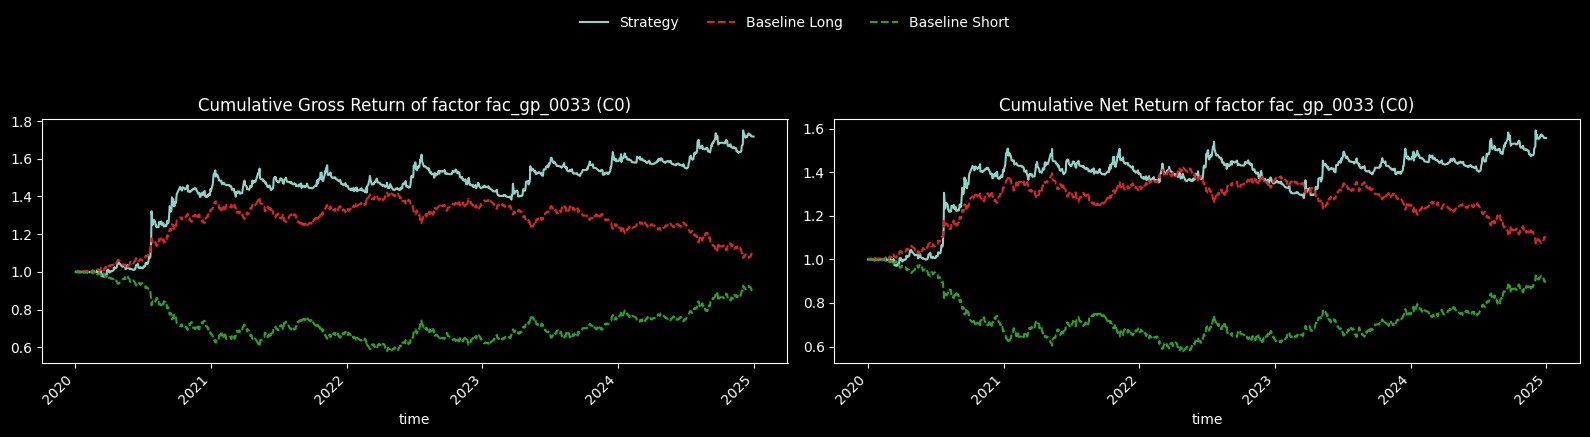

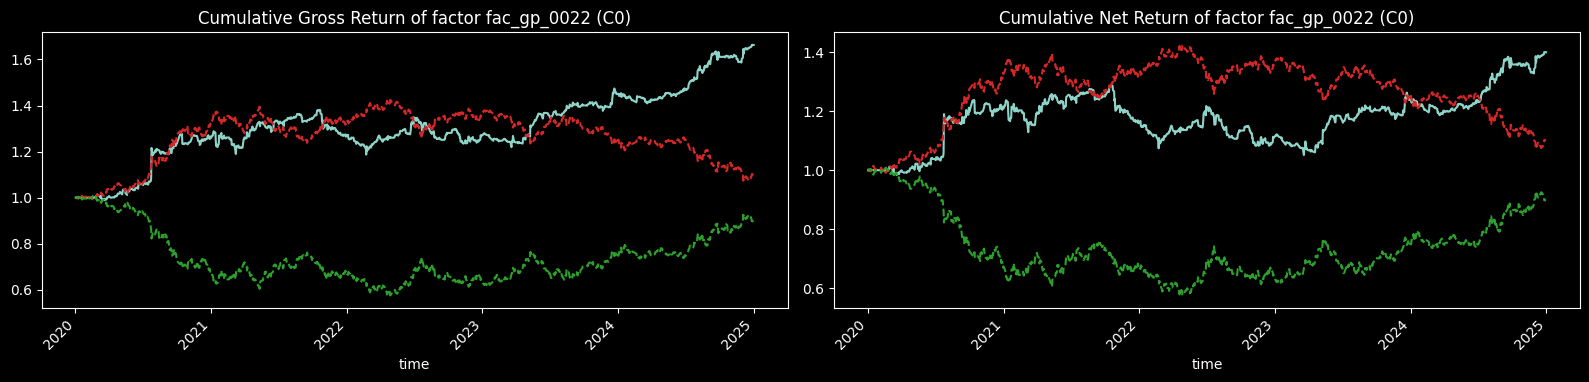

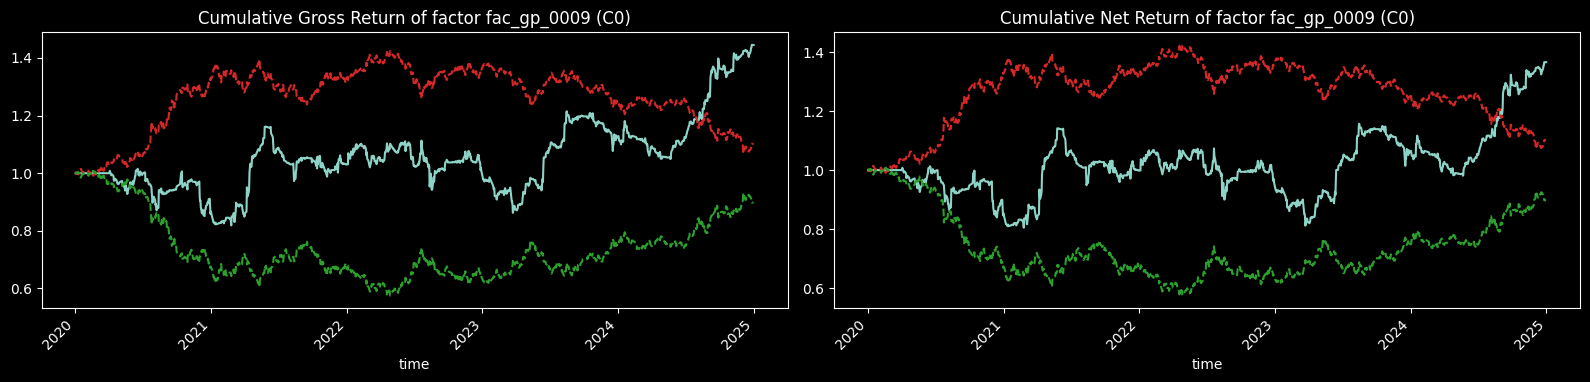

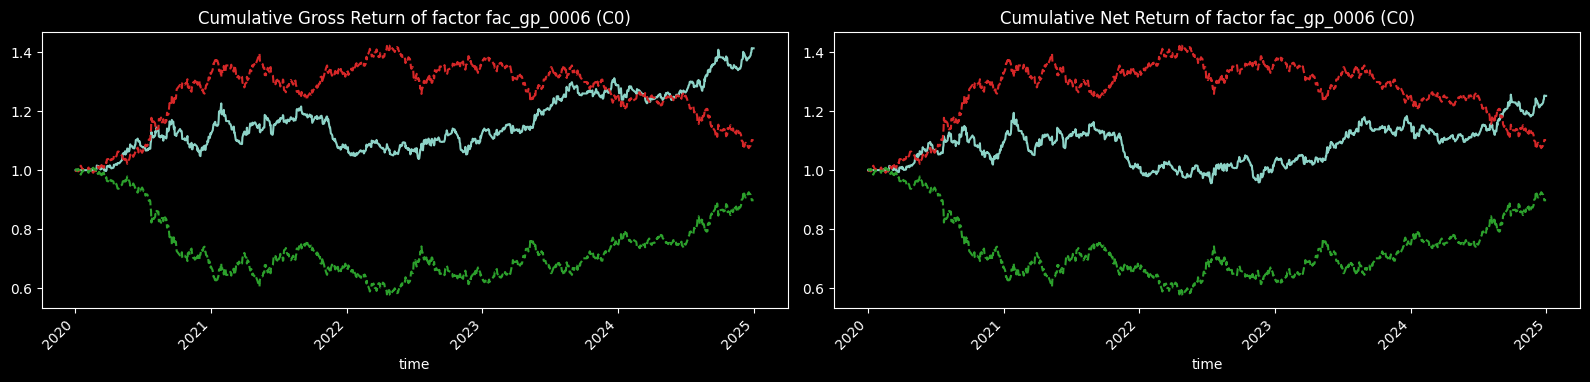

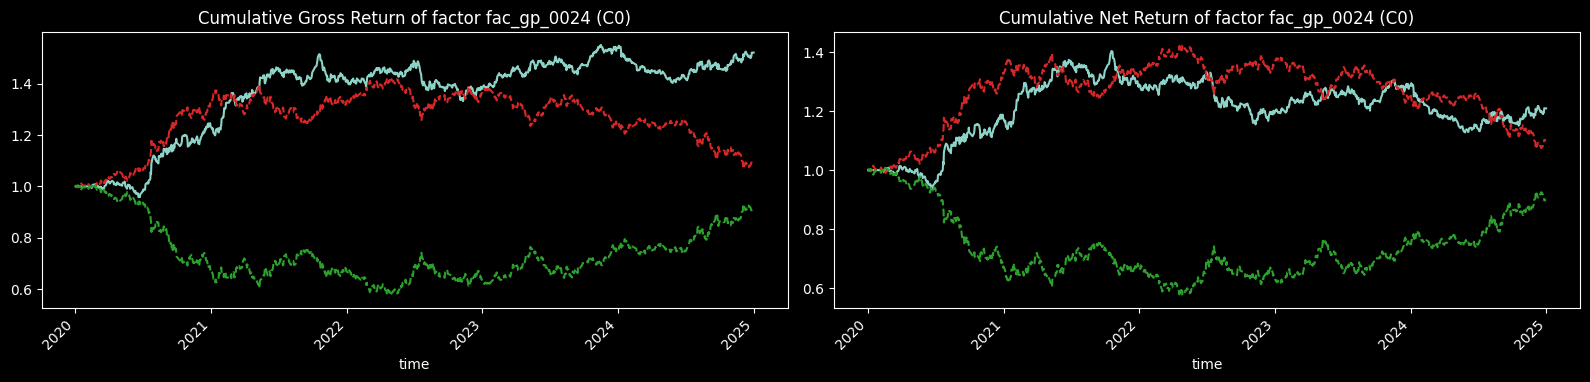

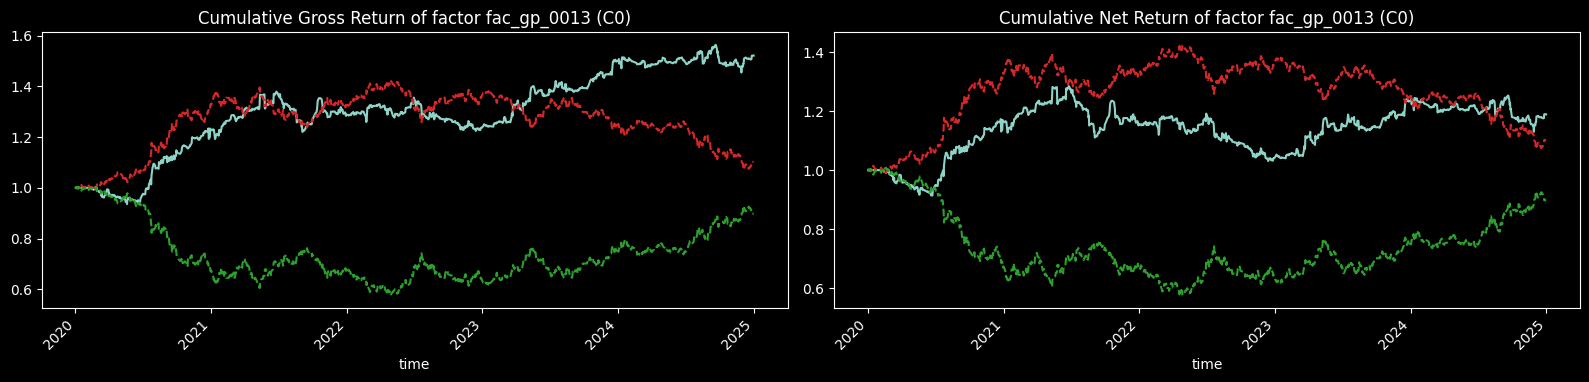

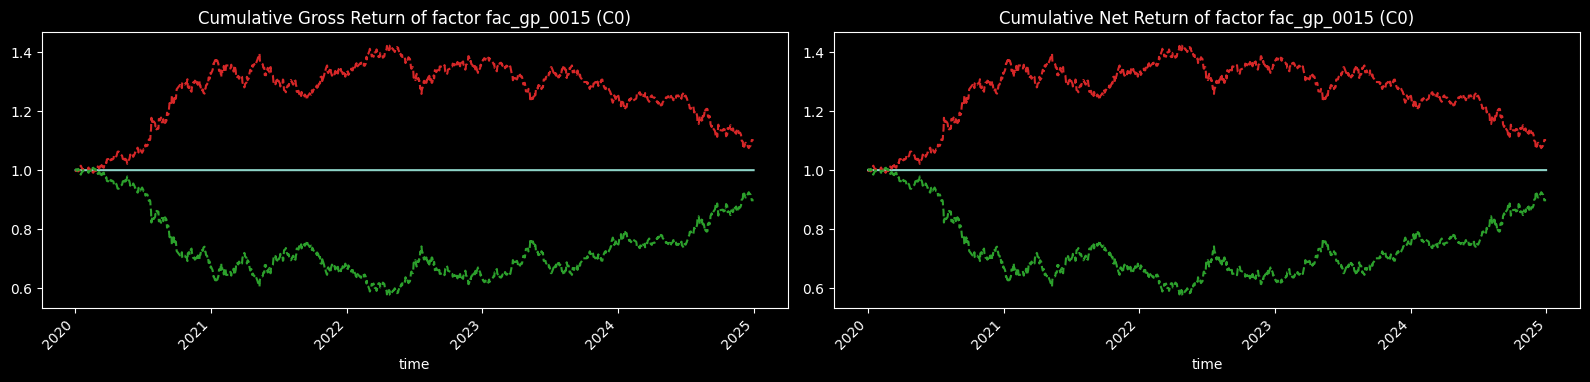

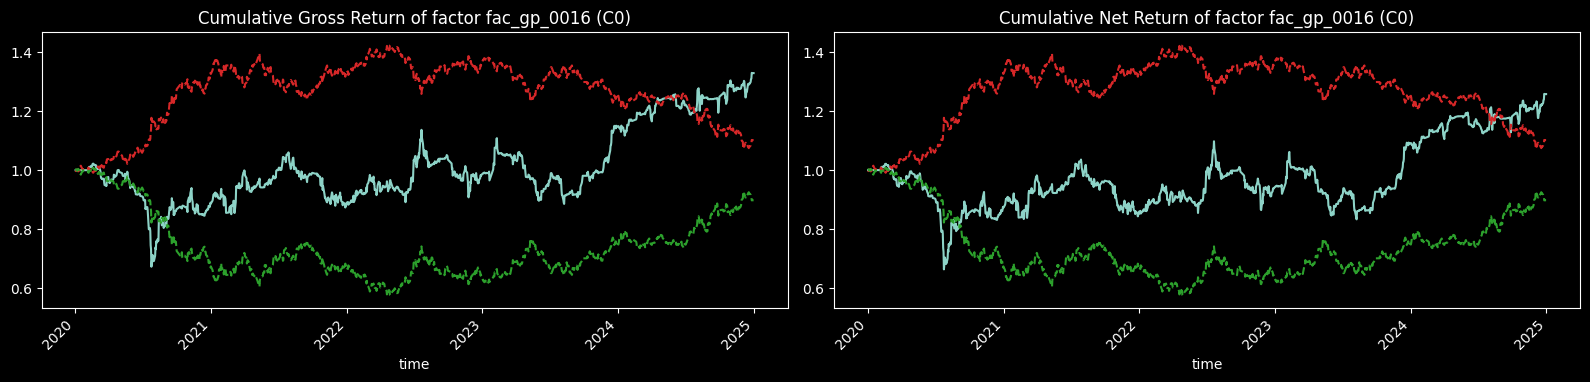

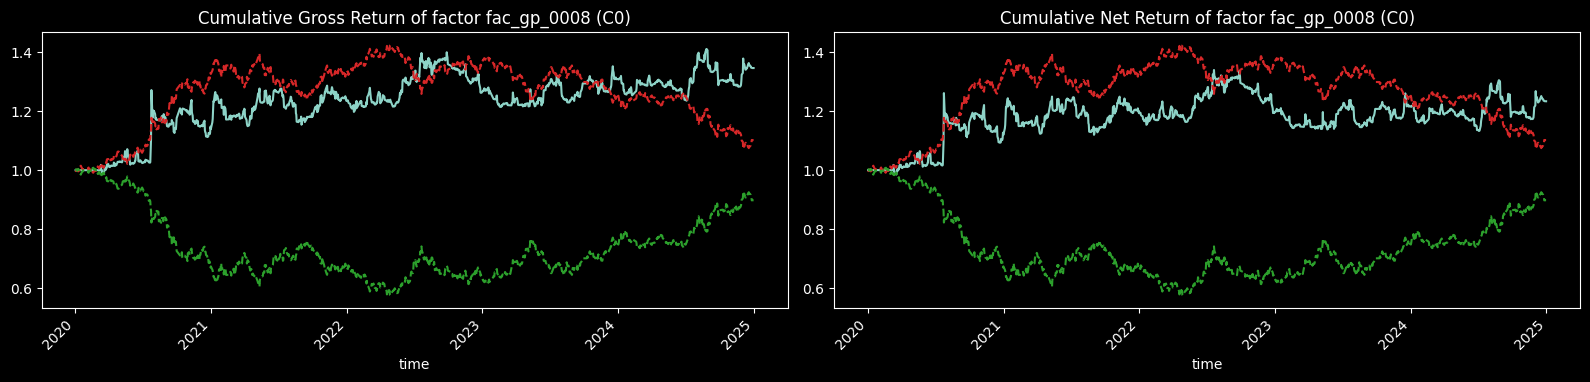

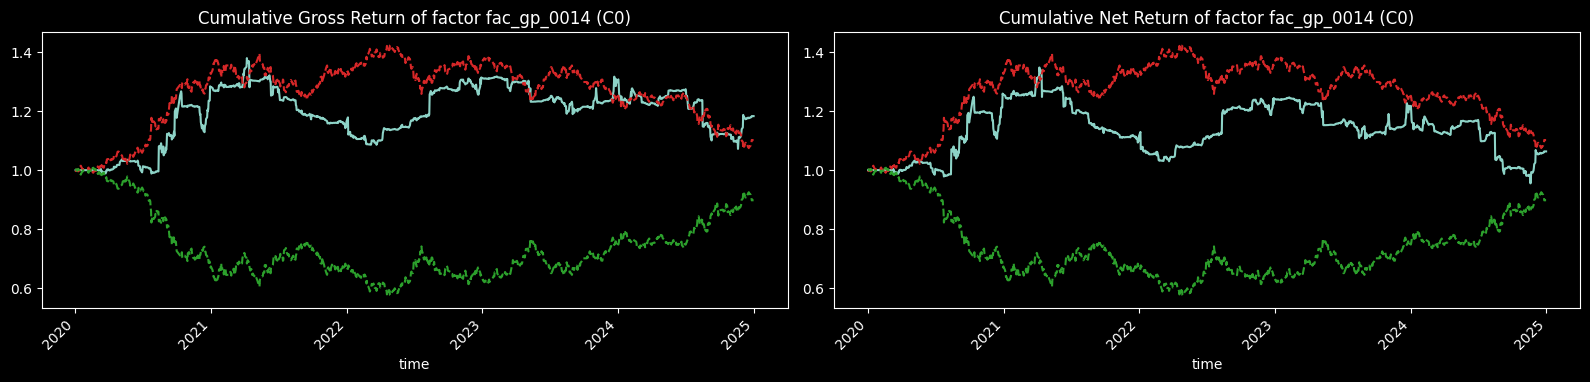

In [10]:
# 净值曲线
start_time = pd.to_datetime('20200101')
end_time = pd.to_datetime('20241231')
bt.plot_nav(start_time=start_time,
            end_time=end_time,
            fc_name=top_fc_name, show_baseline=True)

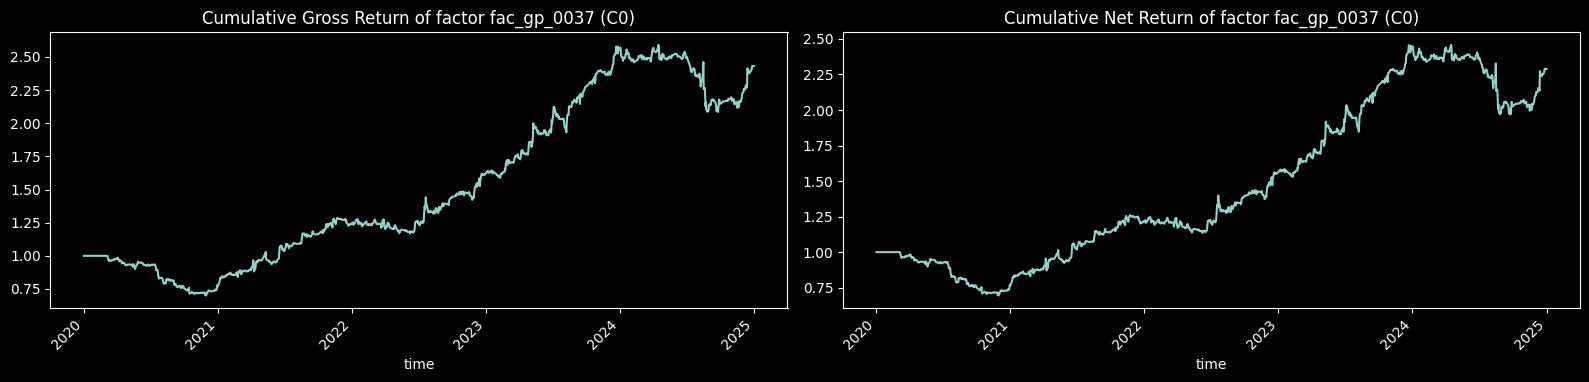

In [10]:
bt.plot_nav(start_time=start_time,
            end_time=end_time,
            fc_name=selected_fc_name_list, show_baseline=False)